In [2]:
import pandas as pd
import numpy as np
import os
import csv
import datetime as d
from datetime import datetime as D
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import random 
import time
import math
import scipy
from scipy import stats
from scipy.stats import norm

In [3]:
%run ../codes/data_input.py
%run ../codes/mcmc_fun.py
%run ../codes/SEIVR.py

In [4]:
data_path = '../data/github/'
import sys
sys.path.append('../codes/')
from data_input import *
from full_contact_matrix import *

serology = pd.read_csv(data_path+'serology/serology_data_complete.csv')

In [8]:
serology.head()

,Unnamed: 0,location,region,month,year,median_donation,race_ethnicity,value,lower,upper,serology_type
0,1,6,bay_area,7,2020,2020-07-17,asian,0.005,0.001,0.031,infection
1,2,6,bay_area,7,2020,2020-07-17,black,0.000,0.000,0.114,infection
2,3,6,bay_area,7,2020,2020-07-17,latino,0.009,0.002,0.039,infection
3,4,6,bay_area,7,2020,2020-07-17,other,0.000,0.000,0.110,infection
4,5,6,bay_area,7,2020,2020-07-17,overall,0.008,0.004,0.014,infection


In [9]:
serology.columns

Index(['Unnamed: 0', 'location', 'region', 'month', 'year', 'median_donation',
       'race_ethnicity', 'value', 'lower', 'upper', 'serology_type'],
      dtype='object')

In [5]:
serology['date'] = serology['year'].astype(str) + '-' + serology['month'].astype(str) + '-10'
serology['date'] = pd.to_datetime(serology['date'])
serology['value'] = pd.to_numeric(serology['value'], errors='coerce') ### the value column is a string, so we need to convert it to float
serology['value'] = serology['value'].astype(np.float64) 

In [6]:
serology_06 = serology[serology['location']== 6]
serology_06_combined = serology_06[serology_06['serology_type']=='infection'].reset_index(drop=True)

In [7]:
serology_37 = serology[serology['location']== 37]
# serology_06_infection = serology_06[serology_06['serology_type']=='infection'].reset_index(drop=True)
serology_37_combined = serology_37[serology_37['serology_type']=='infection'].reset_index(drop=True)

In [22]:
# Sort the DataFrame get the averaged serology rates over regions for the state
n_r = len(race_list_06)
M_sl_rates_06 = np.zeros((3,n_r,len(serology_06_combined['date'].unique())))
# date_list_3 = serology_06_combined['median_donation'].unique()
date_list_3 = serology_06_combined['date'].unique()
n_dates = M_sl_rates_06.shape[2]
vr_list = ['value','lower','upper']
for i,vr_name in enumerate(vr_list):
    for r_idx, r in enumerate(race_list_06):
        df_r = serology_06_combined[serology_06_combined['race_ethnicity'] == r][['date', 'region', vr_name]]
        df_sorted_r = df_r.sort_values(by=['region', 'date']).reset_index(drop=True)
        regions_list_r = df_sorted_r['region'].unique()
        n_regions_r = len(regions_list_r)
        serolog_rates_m = np.zeros((n_regions_r,n_dates))
        for rg_idx, rg in enumerate(regions_list_r):
            serolog_rates_m[rg_idx] = df_sorted_r[df_sorted_r['region'] == rg][vr_name].values
        M_sl_rates_06[i,r_idx,:] = np.nanmean(serolog_rates_m, axis=0)

In [9]:
# Sort the DataFrame get the averaged serology rates over regions for the state
n_r = len(race_list_37)
M_sl_rates_37 = np.zeros((3,n_r,len(serology_37_combined['date'].unique())))
date_list_3 = serology_37_combined['median_donation'].unique()
n_dates = M_sl_rates_37.shape[2]
vr_list = ['value','lower','upper']
for i,vr_name in enumerate(vr_list):
    for r_idx, r in enumerate(race_list_37):
        df_r = serology_37_combined[serology_37_combined['race_ethnicity'] == r][['date', 'region', vr_name]]
        df_sorted_r = df_r.sort_values(by=['region', 'date']).reset_index(drop=True)
        regions_list_r = df_sorted_r['region'].unique()
        n_regions_r = len(regions_list_r)
        serolog_rates_m = np.zeros((n_regions_r,n_dates))
        for rg_idx, rg in enumerate(regions_list_r):
            serolog_rates_m[rg_idx] = df_sorted_r[df_sorted_r['region'] == rg][vr_name].values
        M_sl_rates_37[i,r_idx,:] = np.nanmean(serolog_rates_m, axis=0)

In [10]:
def smooth_array(arr):
    smoothed_array = np.copy(arr)
    rows, cols = arr.shape
    
    for col in range(cols):
        for row in range(1, rows):
            if smoothed_array[row, col] < smoothed_array[row-1, col]:
                # Keep the previous value if a decrease is detected
                smoothed_array[row, col] = smoothed_array[row-1, col]
                
    return smoothed_array

def smooth_array_backward(arr):
    smoothed_array = np.copy(arr)
    rows, cols = arr.shape
    print (rows, cols)
    for col in range(cols):
        for row in range(rows-2, -1, -1): 
            # print ('now', row) # Start from the second-to-last row to the first row
            if smoothed_array[row, col] > smoothed_array[row+1, col]:
                # print (row, 'decreased')
                # Set the current value to the value below if it is greater
                smoothed_array[row, col] = smoothed_array[row+1, col]
                
    return smoothed_array

In [24]:
smoothed_rates_06 = np.zeros((5, n_dates))
smoothed_array = smooth_array(M_sl_rates_06[0,:,:].T) # input is time * race
clipped = np.clip(smoothed_array, M_sl_rates_06[1,:,:].T, M_sl_rates_06[2,:,:].T)
smoothed_rates_06[:,:] = clipped.T
    # actural_inf_06[i,:,:] = N_06[:, np.newaxis] * smoothed_array.T

back_checked_06 = np.zeros((5, n_dates))
back_checked_smoothed_rates_06 = smooth_array_backward(clipped)
back_checked_06 = back_checked_smoothed_rates_06.T

18 5


In [11]:
# actural_inf_37 = np.zeros((3,4, n_dates))
# smoothed_rates_37 = np.zeros((3, 4, n_dates))
# for i in range(3):
#     smoothed_array = smooth_array(M_sl_rates_37[i,:,:].T) # input is time * race
#     smoothed_rates_37[i,:, :] = smoothed_array.T
#     actural_inf_37[i,:,:] = N_37[:, np.newaxis] * smoothed_array.T
#     # actural_inf_37[i,:,:] = N_37[:, np.newaxis] * M_sl_rates_37[i,:,:]

smoothed_rates_37 = np.zeros((4, n_dates))
smoothed_array = smooth_array(M_sl_rates_37[0,:,:].T) # input is time * race
clipped = np.clip(smoothed_array, M_sl_rates_37[1,:,:].T, M_sl_rates_37[2,:,:].T)
smoothed_rates_37[:,:] = clipped.T

back_checked_37 = np.zeros((4, n_dates))
back_checked_smoothed_rates_37 = smooth_array_backward(clipped)
back_checked_37 = back_checked_smoothed_rates_37.T

18 4


asian
white
black
latino
other


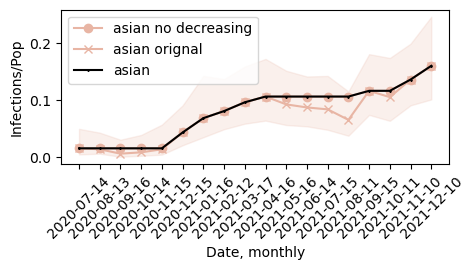

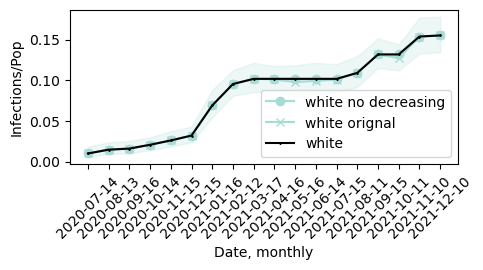

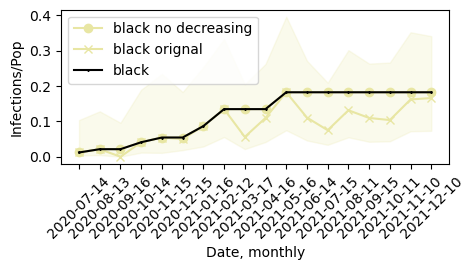

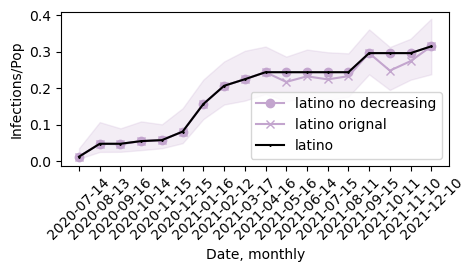

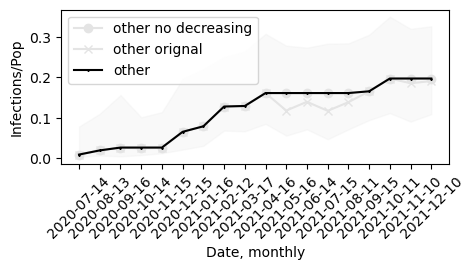

In [26]:

for r_idx in range(5):
    plt.figure(figsize=(5,2))
    r = race_list_06[r_idx]
    print(r)
    plt.plot(date_list_3[:], smoothed_rates_06[r_idx,:], 'o-',label=r+' no decreasing', c = custom_colors[r])
    plt.plot(date_list_3[:], M_sl_rates_06[0,r_idx,:], 'x-',label=r+' orignal',c = custom_colors[r])
    plt.plot(date_list_3[:], back_checked_06[r_idx,:], 'd-',label=r,c = 'black',markersize=1)
    plt.fill_between(date_list_3[:], M_sl_rates_06[1,r_idx,:], M_sl_rates_06[2,r_idx,:], alpha=0.2, color=custom_colors[r])
    # plt.axhline(y=N_06[r_idx],c=custom_colors[r])
    plt.xlabel('Date, monthly')
    plt.ylabel('Infections/Pop')
    plt.xticks(rotation=45)
    # plt.xticks(date_list[:5])
    plt.legend()

In [35]:
back_checked_06[:,9]

array([0.10933333, 0.05966667, 0.144     , 0.15866667, 0.14633333])

In [20]:
# np.savetxt('serology_rates_06.csv',back_checked_06)
back_checked_06 = np.loadtxt('serology_rates_06.csv')

asian
white
black
other


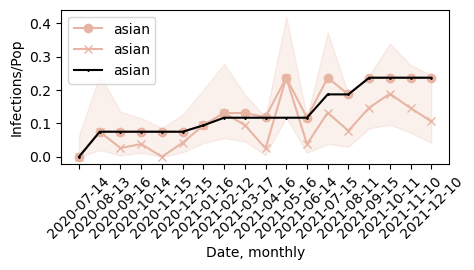

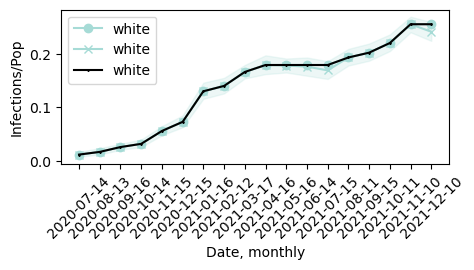

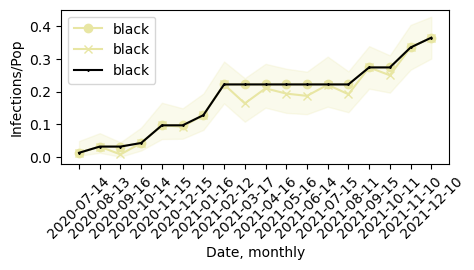

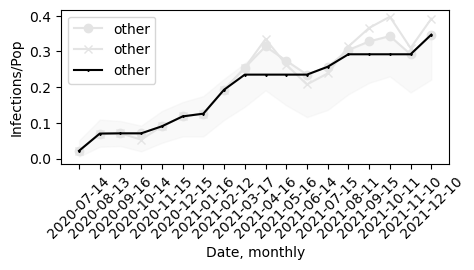

In [27]:
for r_idx in range(4):
    plt.figure(figsize=(5,2))
    r = race_list_37[r_idx]
    print(r)
    plt.plot(date_list_3[:], smoothed_rates_37[r_idx,:], 'o-',label=r, c = custom_colors[r])
    plt.plot(date_list_3[:], M_sl_rates_37[0,r_idx,:], 'x-',label=r,c = custom_colors[r])
    plt.plot(date_list_3[:], back_checked_37[r_idx,:], 'd-',label=r,c = 'black',markersize=1)
    plt.fill_between(date_list_3[:], M_sl_rates_37[1,r_idx,:], M_sl_rates_37[2,r_idx,:], alpha=0.2, color=custom_colors[r])
    # plt.axhline(y=N_06[r_idx],c=custom_colors[r])
    plt.xlabel('Date, monthly')
    plt.ylabel('Infections/Pop')
    plt.xticks(rotation=45)
    # plt.xticks(date_list[:5])
    plt.legend()

In [28]:
np.savetxt('serology_rates_37.csv',back_checked_37)

In [24]:
back_checked_37[1,:10]

array([0.012, 0.017, 0.026, 0.032, 0.056, 0.073, 0.13 , 0.14 , 0.166,
       0.179])

In [16]:
date_list_3[9]

'2021-04-16'